TASK2: EXPLORATORY DATA ANALYSIS(EDA)

2.1-> Analyse transaction trends over the years for each state.
A. Calculate the total number of transactions and total transaction amount for each state over the years.
   Display the result in tabular format.
B. Identify 5 states with the highest transaction volumnes and 5 states with lowest transaction volumes.

In [8]:
# Ans A- TOTAL TRANSACTIONS AND TOTAL AMOUNT PER STATE PER YEAR
import pandas as pd
s_txnusers=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_Txn and Users')
result=s_txnusers.groupby(['State','Year']).agg(
    Total_Transactions=('Transactions','sum'),Total_Amount=('Amount (INR)','sum')).reset_index()
print(result)

                         State  Year  Total_Transactions  Total_Amount
0    Andaman & Nicobar Islands  2018               58021  1.890761e+08
1    Andaman & Nicobar Islands  2019              133104  4.734648e+08
2    Andaman & Nicobar Islands  2020              446274  1.296423e+09
3    Andaman & Nicobar Islands  2021              586166  1.682854e+09
4               Andhra Pradesh  2018            77779112  1.220720e+11
..                         ...   ...                 ...           ...
139                Uttarakhand  2021            44608834  7.727901e+10
140                West Bengal  2018           120011635  1.115887e+11
141                West Bengal  2019           257900590  2.660145e+11
142                West Bengal  2020           304222327  5.527316e+11
143                West Bengal  2021           260151489  5.223720e+11

[144 rows x 4 columns]


In [9]:
# using pivot table
import pandas as pd
s_txnusers=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_Txn and Users')
pivot_table = s_txnusers.pivot_table(
    values=['Transactions', 'Amount (INR)'],
    index='State',
    columns='Year',
    aggfunc='sum'
)

print(pivot_table)

                                      Amount (INR)                \
Year                                          2018          2019   
State                                                              
Andaman & Nicobar Islands             1.890761e+08  4.734648e+08   
Andhra Pradesh                        1.220720e+11  5.377914e+11   
Arunachal Pradesh                     1.127124e+09  3.465824e+09   
Assam                                 1.320755e+10  4.718950e+10   
Bihar                                 6.808569e+10  2.656415e+11   
Chandigarh                            4.976605e+09  1.251134e+10   
Chhattisgarh                          2.213205e+10  7.649396e+10   
Dadra & Nagar Haveli and Daman & Diu  1.584119e+09  3.855924e+09   
Delhi                                 9.575651e+10  3.723972e+11   
Goa                                   2.648633e+09  7.991018e+09   
Gujarat                               6.243806e+10  2.213301e+11   
Haryana                               5.987994e+

In [24]:
# ANS B
# TOP AND BOTTOM 5 STATES BY TRANSACTION VOLUME
import pandas as pd
s_txnusers=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_Txn and Users')
result=s_txnusers.groupby('State')['Transactions'].sum().reset_index(name='Transaction_Volume')
result=result.sort_values(by='Transaction_Volume',ascending=False)
print("TOP 5 STATES WITH HIGHEST TRANSACTION VOLUMES ARE:")
print(result.head())
print("TOP 5 STATES WITH THE LOWEST TRANSACTION VOLUME ARE:")
print(result.tail().sort_values(by='Transaction_Volume'))

TOP 5 STATES WITH HIGHEST TRANSACTION VOLUMES ARE:
             State  Transaction_Volume
15       Karnataka          2981044533
20     Maharashtra          2833670154
31       Telangana          2347430243
1   Andhra Pradesh          1781091169
28       Rajasthan          1382918930
TOP 5 STATES WITH THE LOWEST TRANSACTION VOLUME ARE:
                        State  Transaction_Volume
18                Lakshadweep               71610
0   Andaman & Nicobar Islands             1223565
17                     Ladakh             1880109
23                    Mizoram             2162776
22                  Meghalaya             5648913


INSIGHT-> The state of Karnataka has the highest and Lakshadweep has the lowest transaction volume.

2.2-> Identify the most common transaction type in each state and quarter.
    Display the result in tabular form.

In [22]:
import pandas as pd
s_txnsplit=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_TxnSplit')
result=s_txnsplit.groupby(['State','Quarter','Transaction Type'])['Transactions'].sum().reset_index(name='Transactions')
idx=result.groupby(['State','Quarter'])['Transactions'].idxmax()
rs=result.loc[idx].rename(columns={
    'Transaction Type':'Most Common Transaction Type',
    'Transaction':'Total Transaction'}).sort_values(['State','Quarter'])
print(rs)

                         State  Quarter Most Common Transaction Type  \
3    Andaman & Nicobar Islands        1        Peer-to-peer payments   
9    Andaman & Nicobar Islands        2     Recharge & bill payments   
14   Andaman & Nicobar Islands        3     Recharge & bill payments   
18   Andaman & Nicobar Islands        4        Peer-to-peer payments   
23              Andhra Pradesh        1        Peer-to-peer payments   
..                         ...      ...                          ...   
698                Uttarakhand        4        Peer-to-peer payments   
703                West Bengal        1        Peer-to-peer payments   
708                West Bengal        2        Peer-to-peer payments   
713                West Bengal        3        Peer-to-peer payments   
718                West Bengal        4        Peer-to-peer payments   

     Transactions  
3          138772  
9          180447  
14          84165  
18         110018  
23      255236515  
..            .

2.3-> Determine the device brand with highest number of registered users in each state.

In [28]:
import pandas as pd
s_device=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_DeviceData')
res=s_device.groupby(['State','Brand'])['Registered Users'].sum().reset_index()
idx=res.groupby('State')['Registered Users'].idxmax()
result=res.loc[idx].rename(columns={
    'Brand':'Most Common Brand',
    'Registered Users': 'Total Registered Users'}).sort_values(['State'])
print(result)

                                    State Most Common Brand  \
11              Andaman & Nicobar Islands            Xiaomi   
22                         Andhra Pradesh            Xiaomi   
34                      Arunachal Pradesh            Xiaomi   
46                                  Assam            Xiaomi   
60                                  Bihar            Xiaomi   
73                             Chandigarh            Xiaomi   
85                           Chhattisgarh            Xiaomi   
98   Dadra & Nagar Haveli and Daman & Diu            Xiaomi   
109                                 Delhi            Xiaomi   
120                                   Goa            Xiaomi   
131                               Gujarat            Xiaomi   
143                               Haryana            Xiaomi   
156                      Himachal Pradesh            Xiaomi   
168                       Jammu & Kashmir            Xiaomi   
182                             Jharkhand            Xi

INSIGHT-> The Brand Name XIAOMI is the most common brand type across all states.

2.4-> Create a list of top district per state based on population.

In [35]:
import pandas as pd
d_demo=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='District Demographics')

# check if any duplicate values
res=d_demo.groupby(['State','District'])['Population'].sum().reset_index()
idx=res.groupby('State')['Population'].idxmax()
result=res.loc[idx].rename(columns={
   'District':'Top District',
   'Population':'Max Population'}).sort_values(['State'])
print(result)

                                    State            Top District  \
2               Andaman & Nicobar Islands           South Andaman   
5                          Andhra Pradesh           East Godavari   
31                      Arunachal Pradesh              Papum Pare   
67                                  Assam                  Nagaon   
100                                 Bihar                   Patna   
113                            Chandigarh              Chandigarh   
137                          Chhattisgarh                  Raipur   
142  Dadra & Nagar Haveli and Daman & Diu  Dadra and Nagar Haveli   
150                                 Delhi        North West Delhi   
156                                   Goa               North Goa   
158                               Gujarat               Ahmedabad   
194                               Haryana               Faridabad   
216                      Himachal Pradesh                  Kangra   
231                       Jammu & 

2.5 Calculate the Average Transaction Value(ATV) for each state.
   A. Display the result in Tabular Format.
   B. Identify top 5 states with highest and lowest ATV.

In [45]:
import pandas as pd
s_txnusers=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_Txn and Users')
result=s_txnusers.groupby('State')['ATV (INR)'].mean().round(2).reset_index()
print(result)

# TOP 5 AND BOTTOM 5 STATES
result=result.sort_values(by='ATV (INR)',ascending=False)
print("TOP 5 STATES WITH HIGHEST ATV")
print(result.head())
print("BOTTOM 5 STATES WITH LOWEST ATV")
print(result.tail().sort_values(by='ATV (INR)'))

                                   State  ATV (INR)
0              Andaman & Nicobar Islands    3159.27
1                         Andhra Pradesh    1748.09
2                      Arunachal Pradesh    2638.32
3                                  Assam    2008.50
4                                  Bihar    2023.32
5                             Chandigarh    2113.80
6                           Chhattisgarh    1650.82
7   Dadra & Nagar Haveli and Daman & Diu    1487.40
8                                  Delhi    1589.84
9                                    Goa    1895.26
10                               Gujarat    1696.10
11                               Haryana    1831.84
12                      Himachal Pradesh    1825.34
13                       Jammu & Kashmir    2508.51
14                             Jharkhand    1632.34
15                             Karnataka    1517.39
16                                Kerala    1671.44
17                                Ladakh    3408.22
18          

INSIGHT-> LADAKH has the highest ATV while WEST BENGAL has the lowest ATV.

2.6-> Analyse app usage trends.
 A. Calculate the total number of app opens over the years and quarters for each state. Display in the tabular format.
 B. Identify trends in app usage by creating a line plot showing the number of app opens over time for a selected state.

                         State  Year  Quarter  App Opens
0    Andaman & Nicobar Islands  2018        1          0
1    Andaman & Nicobar Islands  2018        2          0
2    Andaman & Nicobar Islands  2018        3          0
3    Andaman & Nicobar Islands  2018        4          0
4    Andaman & Nicobar Islands  2019        1          0
..                         ...   ...      ...        ...
499                West Bengal  2020        2  198589332
500                West Bengal  2020        3  246554831
501                West Bengal  2020        4  291721919
502                West Bengal  2021        1  316832674
503                West Bengal  2021        2  275341466

[504 rows x 4 columns]


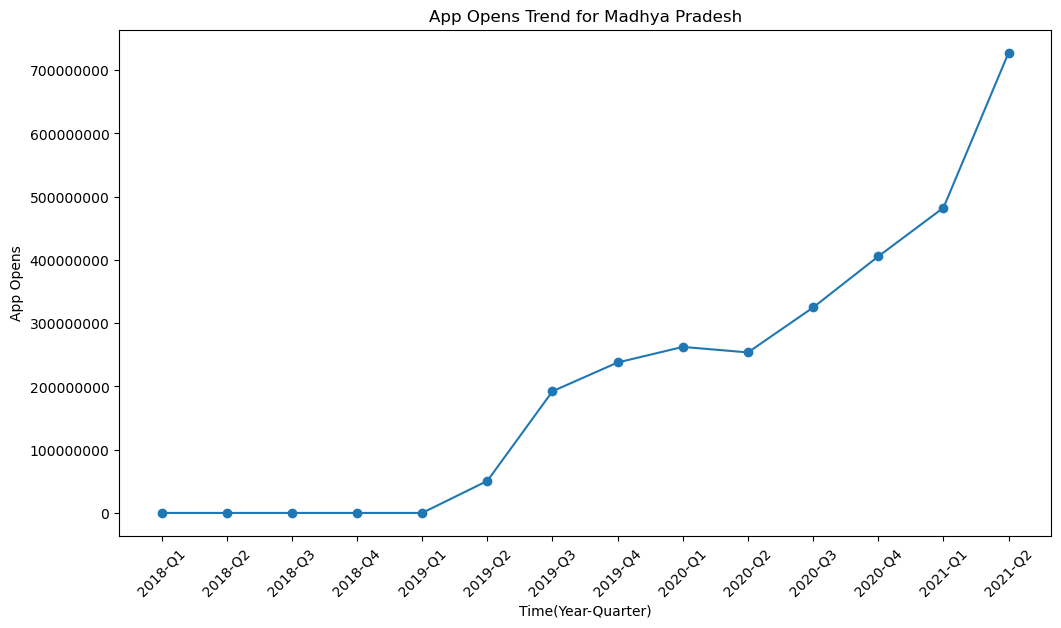

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
s_txnusers=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_Txn and Users')
res=s_txnusers.groupby(['State','Year','Quarter'])['App Opens'].sum().reset_index()
print(res)

# TIME BASED DATA FOR A SELECTED STATE
state_name='Madhya Pradesh'
df_state=res[res['State']==state_name].copy()
df_state['Time']=df_state['Year'].astype(str)+'-Q' + df_state['Quarter'].astype(str)
df_state=df_state.sort_values(['Year','Quarter'])

# PLOT A LINE CHART
plt.figure(figsize=(10,6))
plt.plot(df_state['Time'],df_state['App Opens'],marker='o')
plt.title(f'App Opens Trend for {state_name}')
plt.xlabel('Time(Year-Quarter)')
plt.ylabel('App Opens')
plt.tight_layout()
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain',axis='y')  # to remove scientific notation
plt.show()

INSIGHT-> The app opens have increased alot through time.

2.7-> Distribution of Transaction Types
   -> Create a bar chart showing the distribution of different transaction types for each state for the most recent quarter in the dataset.

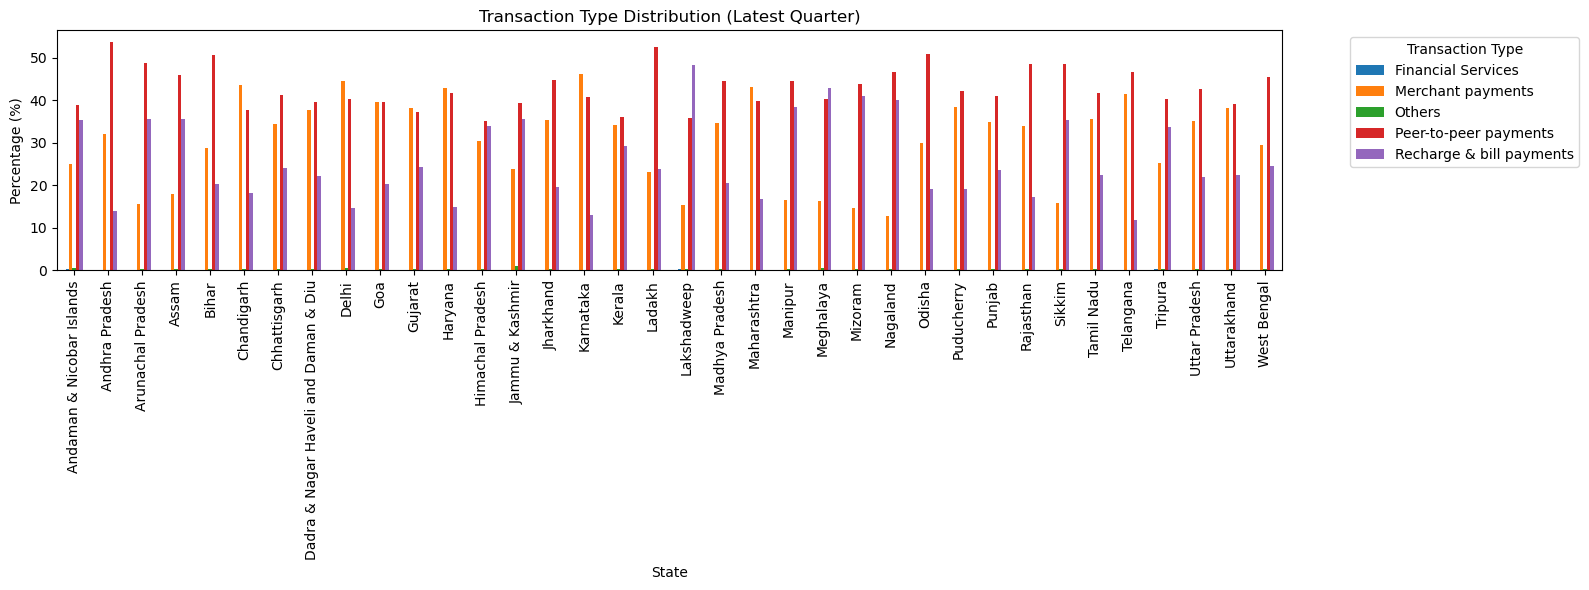

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
s_txnsplit=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_TxnSplit')
latest_year=s_txnsplit['Year'].max()
latest_quarter=s_txnsplit[s_txnsplit['Year']==latest_year]['Quarter'].max()

# FILTER THE DATA FOR THE LATEST YEAR AND QUARTER
latest_data=s_txnsplit[(s_txnsplit['Year']==latest_year) & (s_txnsplit['Quarter']==latest_quarter)]

# Aggregate and convert to pivot for stacking
fdata=latest_data.groupby(['State','Transaction Type'])['Transactions'].sum().reset_index()
pivot=fdata.pivot(index='State',columns='Transaction Type',values='Transactions').fillna(0)
pivot_percent=pivot.div(pivot.sum(axis=1), axis=0) * 100   #convert to percentage for better visualisation

# PLOT THE LATEST AGGREGATED DATA
pivot_percent.plot(kind='bar',figsize=(16,6))
plt.title('Transaction Type Distribution (Latest Quarter)')
plt.xlabel('State')
plt.ylabel('Percentage (%)')
plt.legend(title='Transaction Type', bbox_to_anchor=(1.05,1)) #topright(1,1)
plt.tight_layout()
plt.show()

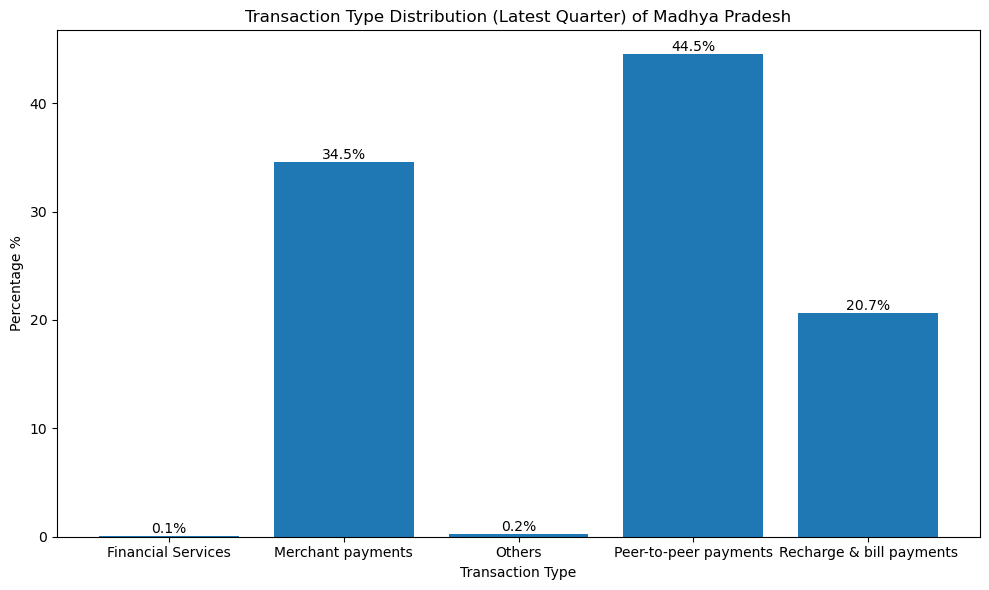

In [73]:
import pandas as pd
s_txnsplit=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_TxnSplit')
latest_year=s_txnsplit['Year'].max()
latest_quarter=s_txnsplit[s_txnsplit['Year']==latest_year]['Quarter'].max()

# FILTER THE DATA FOR THE LATEST YEAR AND QUARTER
latest_data=s_txnsplit[(s_txnsplit['Year']==latest_year) & (s_txnsplit['Quarter']==latest_quarter)]

# Aggregate
fdata=latest_data.groupby(['State','Transaction Type'])['Transactions'].sum().reset_index()
                     
# For a specific state
state_name='Madhya Pradesh'
fdata=fdata[fdata['State']==state_name]
fdata['Percentage']=(fdata['Transactions']/fdata['Transactions'].sum()*100)

# PLOT A SPECIFIC BAR CHART
plt.figure(figsize=(10,6))
bars=plt.bar(fdata['Transaction Type'],fdata['Percentage'])

# for data labels on the top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.1f}%',
             ha='center',
             va='bottom')
plt.title(f'Transaction Type Distribution (Latest Quarter) of {state_name}')
plt.xlabel('Transaction Type')
plt.ylabel('Percentage %')
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

INSIGHT-> Through a bar graph for a state of MADHYA PRADESH, Peer-to-peer payments has highest percentage of transaction type.

2.8-> Find the unique mapping between district name and district code.
    A. Identify the unique mapping between district names and district codes from the dataset.
    B. Create and export the csv file.

In [77]:
mapping=(d_demo[['District','Code']].drop_duplicates().sort_values('District').reset_index(drop=True))
mapping.to_csv(r"C:\Users\sonali\Downloads\Mapping_District.csv",index=False)